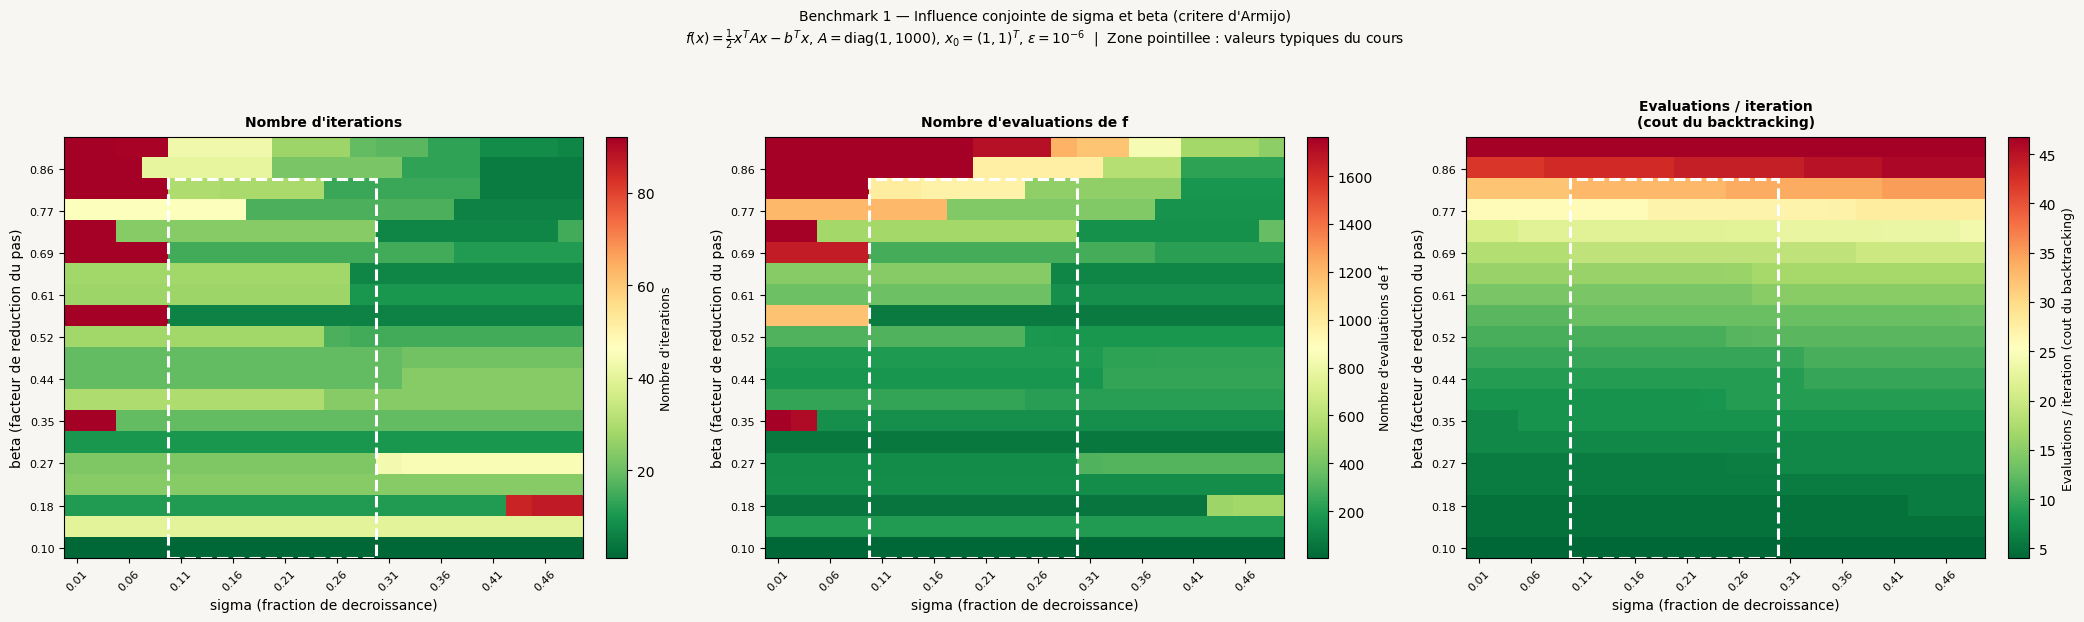

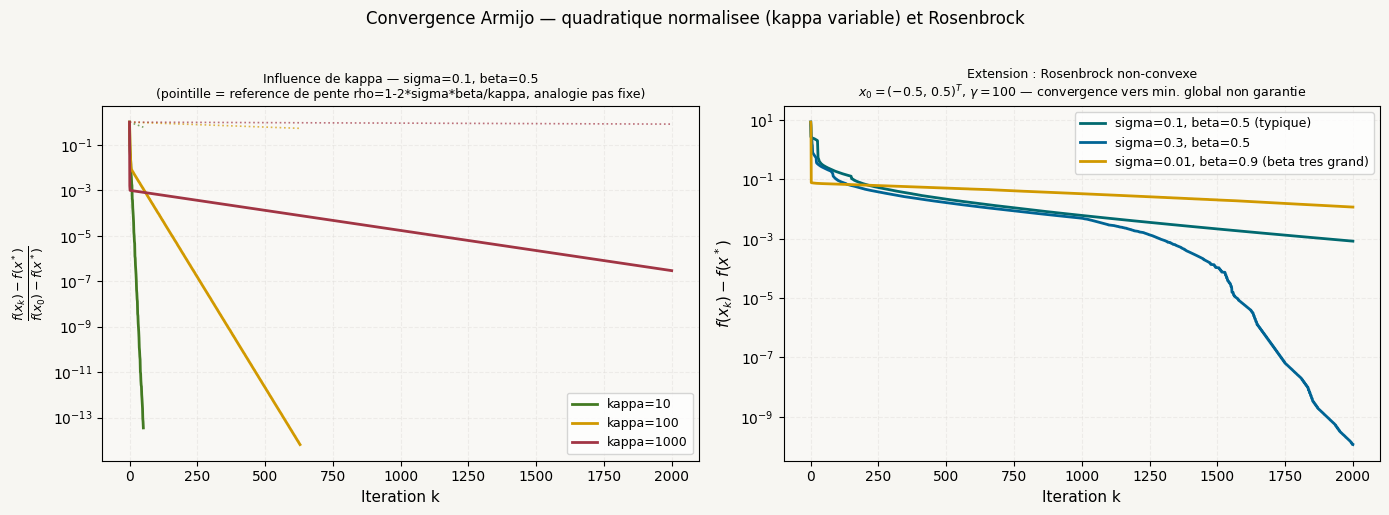

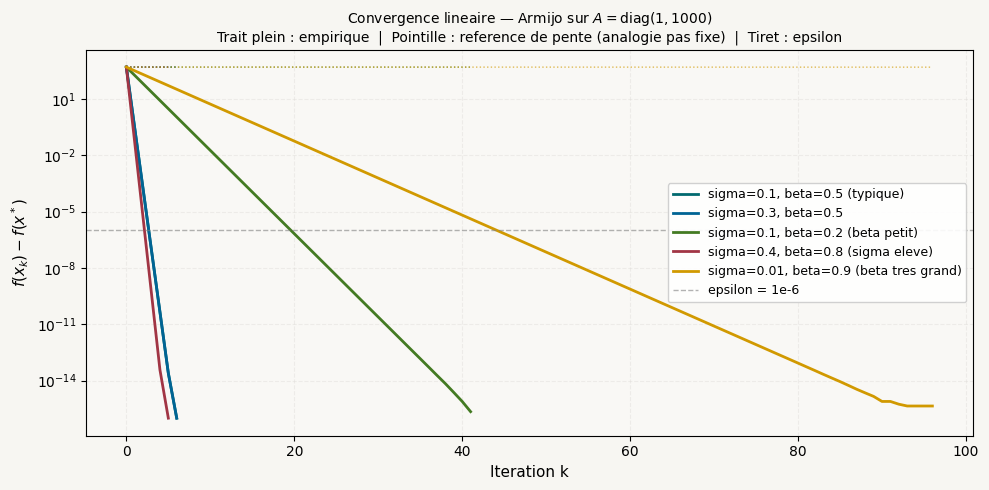

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

%matplotlib inline

np.random.seed(42)
x0 = np.array([1.0, 1.0])

# ── Fonctions quadratiques ─────────────────────────────────────────────
def make_quadratic(kappa):
    A = np.diag([1.0, float(kappa)])
    b = np.array([1.0, 1.0])
    x_star = np.linalg.solve(A, b)
    f_star = 0.5 * x_star @ A @ x_star - b @ x_star
    f    = lambda x: 0.5 * x @ A @ x - b @ x
    grad = lambda x: A @ x - b
    return A, b, x_star, f_star, f, grad

A, b, x_star, f_star, f, grad_f = make_quadratic(1000)

# ── Rosenbrock ─────────────────────────────────────────────────────────
def rosenbrock(x, gamma=100):
    return (x[0] - 1)**2 + gamma * (x[0]**2 - x[1])**2

def grad_rosenbrock(x, gamma=100):
    return np.array([
        2*(x[0] - 1) + 4*gamma*x[0]*(x[0]**2 - x[1]),
        -2*gamma*(x[0]**2 - x[1])
    ])

# ── Descente Armijo ────────────────────────────────────────────────────
def armijo_descent(func, grad_func, x0, sigma, beta, max_iter=10000, tol=1e-6):
    x = x0.copy()
    n_iter, n_evals, converged = 0, 0, False
    for k in range(max_iter):
        g = grad_func(x)
        if np.linalg.norm(g) < tol:
            converged = True
            break
        d = -g
        alpha = 1.0
        while True:
            n_evals += 1  # compter TOUTES les evaluations, y compris celle qui passe
            if func(x + alpha * d) <= func(x) + sigma * alpha * (g @ d):
                break
            alpha *= beta
        x = x + alpha * d
        n_iter += 1
    return n_iter, n_evals, converged

# MODIFICATION : ajout du parametre normalize=False
def armijo_descent_trace(func, grad_func, x0, sigma, beta, f_star=None, max_iter=2000, tol=1e-6, normalize=False):
    x = x0.copy()
    ref = f_star if f_star is not None else func(x0)
    f0 = func(x) - ref  # valeur initiale sauvegardee pour la normalisation
    trace = [f0]
    for k in range(max_iter):
        g = grad_func(x)
        if np.linalg.norm(g) < tol:
            break
        d = -g
        alpha = 1.0
        while True:
            if func(x + alpha * d) <= func(x) + sigma * alpha * (g @ d):
                break
            alpha *= beta
        x = x + alpha * d
        trace.append(max(func(x) - ref, 1e-16))
    trace = np.array(trace)
    # MODIFICATION : division de tout le tableau par f0 si normalize=True
    if normalize and f0 > 0:
        trace = trace / f0
    return trace

# ══════════════════════════════════════════════════════════════════════
# GRILLE (sigma, beta)
# ══════════════════════════════════════════════════════════════════════
sigmas = np.linspace(0.01, 0.49, 20)
betas  = np.linspace(0.1,  0.9,  20)

iters_grid    = np.zeros((len(betas), len(sigmas)))
evals_grid    = np.zeros((len(betas), len(sigmas)))
diverged_mask = np.zeros((len(betas), len(sigmas)), dtype=bool)

for i, sigma in enumerate(sigmas):
    for j, beta in enumerate(betas):
        n_iter, n_evals, conv = armijo_descent(f, grad_f, x0, sigma, beta)
        iters_grid[j, i]  = n_iter
        evals_grid[j, i]  = n_evals
        diverged_mask[j, i] = not conv

# Metrique bonus : cout moyen du backtracking par iteration
cost_per_iter = np.where(iters_grid > 0, evals_grid / iters_grid, np.nan)

# ══════════════════════════════════════════════════════════════════════
# FIGURE 1 — 3 Heatmaps : iterations / evaluations / cout backtracking
# ══════════════════════════════════════════════════════════════════════
iters_clipped = np.clip(iters_grid, None, np.percentile(iters_grid, 95))
evals_clipped = np.clip(evals_grid, None, np.percentile(evals_grid, 95))
cost_clipped  = np.clip(cost_per_iter, None, np.percentile(
                    cost_per_iter[~np.isnan(cost_per_iter)], 95))

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.patch.set_facecolor("#f7f6f2")

datasets = [
    (iters_clipped,  "Nombre d'iterations"),
    (evals_clipped,  "Nombre d'evaluations de f"),
    (cost_clipped,   "Evaluations / iteration\n(cout du backtracking)"),
]

for ax, (data, title) in zip(axes, datasets):
    ax.set_facecolor("#f9f8f5")
    im = ax.imshow(data, aspect="auto", origin="lower", cmap="RdYlGn_r", interpolation="nearest")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(title.replace("\n", " "), fontsize=9)

    if diverged_mask.any():
        div_overlay = np.ma.masked_where(~diverged_mask, np.ones_like(diverged_mask, dtype=float))
        ax.imshow(div_overlay, aspect="auto", origin="lower", cmap="gray",
                  alpha=0.7, interpolation="nearest", zorder=3)

    xticks = np.arange(0, len(sigmas), 2)
    yticks = np.arange(0, len(betas),  2)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{sigmas[i]:.2f}" for i in xticks], rotation=45, fontsize=8)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{betas[i]:.2f}" for i in yticks], fontsize=8)
    ax.set_xlabel("sigma (fraction de decroissance)", fontsize=10)
    ax.set_ylabel("beta (facteur de reduction du pas)", fontsize=10)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)

    s_lo = np.argmin(np.abs(sigmas - 0.10))
    s_hi = np.argmin(np.abs(sigmas - 0.30))
    b_lo = np.argmin(np.abs(betas  - 0.10))
    b_hi = np.argmin(np.abs(betas  - 0.80))
    rect = Rectangle((s_lo-0.5, b_lo-0.5), s_hi-s_lo+1, b_hi-b_lo+1,
                      linewidth=2.2, edgecolor="white", facecolor="none",
                      linestyle="--", zorder=5)
    ax.add_patch(rect)

fig.suptitle(
    "Benchmark 1 — Influence conjointe de sigma et beta (critere d'Armijo)\n"
    r"$f(x)=\frac{1}{2}x^TAx-b^Tx$, $A=\mathrm{diag}(1,1000)$, $x_0=(1,1)^T$, $\varepsilon=10^{-6}$"
    "  |  Zone pointillee : valeurs typiques du cours",
    fontsize=10, y=1.03
)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════
# FIGURE 2 — Convergence kappa variable (gauche) + Rosenbrock (droite)
# MODIFICATIONS :
#   - normalize=True sur le panneau gauche => toutes les courbes partent de 1
#   - ylabel mis a jour
#   - reference de pente part de 1 (au lieu de trace[0])
#   - label "reference de pente" au lieu de "borne theorique"
#   - titre Rosenbrock mentionne que la convergence globale n'est pas garantie
# ══════════════════════════════════════════════════════════════════════
kappas       = [10, 100, 1000]
kappa_colors = ["#437a22", "#d19900", "#a13544"]

combos_rb = [
    (0.1,  0.5, "#01696f", "sigma=0.1, beta=0.5 (typique)"),
    (0.3,  0.5, "#006494", "sigma=0.3, beta=0.5"),
    (0.01, 0.9, "#d19900", "sigma=0.01, beta=0.9 (beta tres grand)"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#f7f6f2")

sigma_th, beta_th = 0.1, 0.5

ax = axes[0]
ax.set_facecolor("#f9f8f5")
for kappa_val, color in zip(kappas, kappa_colors):
    _, _, x_star_k, f_star_k, fk, gk = make_quadratic(kappa_val)
    x0_k = x_star_k + np.array([1.0, 1.0])
    # MODIFICATION : normalize=True => toutes les courbes partent de 1
    trace = armijo_descent_trace(fk, gk, x0_k, sigma=sigma_th, beta=beta_th,
                                 f_star=f_star_k, normalize=True)
    ax.semilogy(trace, color=color, linewidth=2, label=f"kappa={kappa_val}")

    # MODIFICATION : reference de pente part de 1 (analogie pas fixe)
    rho = min(max(1.0 - 2 * sigma_th * beta_th * 1.0 / kappa_val, 0.0), 0.9999)
    k_arr = np.arange(len(trace))
    ax.semilogy(k_arr, np.maximum(rho**k_arr, 1e-16),
                color=color, linewidth=1.2, linestyle=":", alpha=0.7)

ax.set_xlabel("Iteration k", fontsize=11)
# MODIFICATION : ylabel normalise
ax.set_ylabel(r"$\frac{f(x_k) - f(x^*)}{f(x_0) - f(x^*)}$", fontsize=13)
# MODIFICATION : titre plus prudent sur la borne
ax.set_title("Influence de kappa — sigma=0.1, beta=0.5\n"
             "(pointille = reference de pente rho=1-2*sigma*beta/kappa, analogie pas fixe)", fontsize=9)
ax.legend(fontsize=9)
ax.grid(True, which="both", linestyle="--", alpha=0.4, color="#dcd9d5")

ax = axes[1]
ax.set_facecolor("#f9f8f5")
x0_rb = np.array([-0.5, 0.5])
for sigma, beta, color, label in combos_rb:
    trace = armijo_descent_trace(rosenbrock, grad_rosenbrock, x0_rb, sigma, beta, f_star=0.0)
    ax.semilogy(trace, color=color, linewidth=2, label=label)

ax.set_xlabel("Iteration k", fontsize=11)
ax.set_ylabel(r"$f(x_k) - f(x^*)$", fontsize=11)
# MODIFICATION : titre mentionne que la convergence globale n'est pas garantie
ax.set_title("Extension : Rosenbrock non-convexe\n"
             r"$x_0=(-0.5,\,0.5)^T$, $\gamma=100$ — convergence vers min. global non garantie",
             fontsize=9)
ax.legend(fontsize=9)
ax.grid(True, which="both", linestyle="--", alpha=0.4, color="#dcd9d5")

fig.suptitle("Convergence Armijo — quadratique normalisee (kappa variable) et Rosenbrock",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════
# FIGURE 3 — Multi (sigma, beta) sur kappa=1000
# MODIFICATION : label "reference de pente" au lieu de "borne theorique"
# ══════════════════════════════════════════════════════════════════════
combos_orig = [
    (0.1,  0.5, "#01696f", "sigma=0.1, beta=0.5 (typique)"),
    (0.3,  0.5, "#006494", "sigma=0.3, beta=0.5"),
    (0.1,  0.2, "#437a22", "sigma=0.1, beta=0.2 (beta petit)"),
    (0.4,  0.8, "#a13544", "sigma=0.4, beta=0.8 (sigma eleve)"),
    (0.01, 0.9, "#d19900", "sigma=0.01, beta=0.9 (beta tres grand)"),
]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#f7f6f2")
ax.set_facecolor("#f9f8f5")

m_val, L_val = 1.0, 1000.0  # valeurs propres de A = diag(1, 1000)

for sigma, beta, color, label in combos_orig:
    trace = armijo_descent_trace(f, grad_f, x0, sigma, beta, f_star=f_star)
    ax.semilogy(trace, color=color, linewidth=2, label=label)

    # MODIFICATION : label "reference de pente" (analogie pas fixe, non prouvee pour Armijo)
    rho = min(max(1.0 - 2 * sigma * beta * m_val / L_val, 0.0), 0.9999)
    k_arr = np.arange(len(trace))
    ax.semilogy(k_arr, np.maximum(trace[0] * rho**k_arr, 1e-16),
                color=color, linewidth=1.0, linestyle=":", alpha=0.65)

ax.axhline(1e-6, color="gray", linewidth=1, linestyle="--", alpha=0.6, label="epsilon = 1e-6")
ax.set_xlabel("Iteration k", fontsize=11)
ax.set_ylabel(r"$f(x_k) - f(x^*)$", fontsize=11)
ax.set_title(
    r"Convergence lineaire — Armijo sur $A=\mathrm{diag}(1,1000)$" + "\n"
    "Trait plein : empirique  |  Pointille : reference de pente (analogie pas fixe)  |  Tiret : epsilon",
    fontsize=10
)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, which="both", linestyle="--", alpha=0.4, color="#dcd9d5")
plt.tight_layout()
plt.show()